In [1]:
import os, sys
import numpy as np

from noah2 import data as D
from causalflow import causalflow

import torch

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
# read CRS non-participant data
DNoah = D.Noah2()
fema = DNoah._read_data_full()
is_participant = DNoah._participants(fema)
fema = fema[~is_participant]

# compile training data
columns = DNoah._columns()[:8]
test_data = np.array([np.array(fema[col]) for col in columns]).T
# reduce dynamical range
test_data[:,0] = np.log10(test_data[:,0])
test_data[:,3] = np.log10(test_data[:,3])
test_data[:,4] = np.log10(test_data[:,4])

Ntrain = int(test_data.shape[0] * 0.9)

# shufftle training data
ishfl = np.arange(test_data.shape[0])
np.random.seed(42)
np.random.shuffle(ishfl)
test_data = test_data[ishfl][Ntrain:] # reserved 10% for testing

In [4]:
Cflow = causalflow.CausalFlowB('control') # non-participant is the base distribution

# load flow
flows = Cflow._load_flows_optuna('flow.nonpart', '/scratch/gpfs/chhahn/noah/noah2/qphi/', verbose=True)

select 5 out of 18 flows


In [5]:
alpha, ecp = Cflow._validate(flows, test_data[:,1:], test_data[:,0][:,None], Nsample=10000, verbose=True)

Test Sample:   0%|          | 0/39122 [00:00<?, ?it/s]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


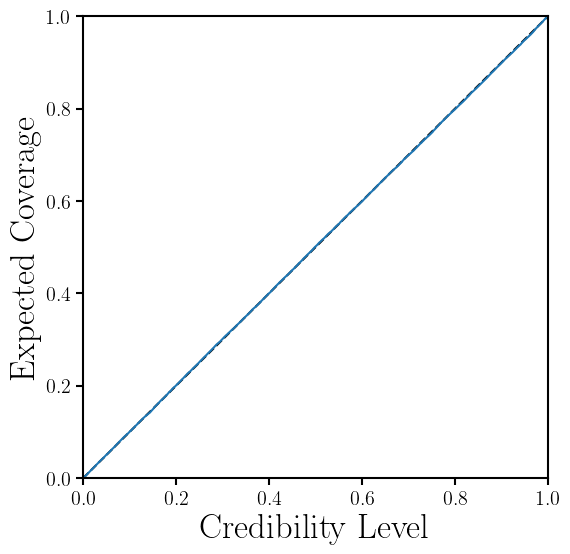

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.plot([0, 1], [0, 1], ls="--", color="k")
ax.plot(alpha, ecp, color='C0') 
ax.legend(loc='lower right', handletextpad=0.1, fontsize=25)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0., 1.)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0., 1.)
plt.show()